In [ ]:
# Dyslexia Detection & Learning Support Pipeline

#Clean, end-to-end notebook to load datasets, train CNN + EfficientNet-B0 models, resume from checkpoints, and evaluate on a balanced test set containing both normal and dyslexic handwriting samples.


In [1]:
# ------------------------------------------------------------------
# Imports & global configuration
# ------------------------------------------------------------------
import os
import copy
from collections import defaultdict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

# Notebook-wide configuration
SEED = 42
DATASET_FRACTION = float(os.environ.get("EFFNET_DATASET_FRACTION", 0.35))
DATASET_FRACTION = min(max(DATASET_FRACTION, 0.05), 1.0)
EMNIST_TRAIN_FRACTION = float(os.environ.get("EMNIST_TRAIN_FRACTION", 0.25))
EMNIST_TRAIN_FRACTION = min(max(EMNIST_TRAIN_FRACTION, 0.05), 1.0)
CHECKPOINT_DIR = "/kaggle/working/effnet_checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "efficientnet_b0_state.pt")
RESUME_TRAINING = True
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Reproducibility & device
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Resume training: {RESUME_TRAINING}")
print(f"Train subset fraction: {DATASET_FRACTION:.2f}")
print(f"EMNIST train fraction: {EMNIST_TRAIN_FRACTION:.2f}")

BINARY_CLASS_NAMES = ["Normal", "Dyslexia"]


def remap_synthetic_to_binary(ds: ImageFolder) -> ImageFolder:
    """Collapse dyslexia folders into Normal (0) vs Dyslexia (1)."""
    idx_to_binary = {}
    for class_name, idx in ds.class_to_idx.items():
        binary_label = 0 if class_name.lower() == "normal" else 1
        idx_to_binary[idx] = binary_label
    ds.samples = [(path, idx_to_binary[label]) for path, label in ds.samples]
    if hasattr(ds, "imgs"):
        ds.imgs = ds.samples
    if hasattr(ds, "targets"):
        ds.targets = [idx_to_binary[label] for label in ds.targets]
    ds.class_to_idx = {name: idx for idx, name in enumerate(BINARY_CLASS_NAMES)}
    ds.classes = BINARY_CLASS_NAMES
    ds.target_transform = None
    return ds


Using device: cuda
Checkpoint dir: /kaggle/working/effnet_checkpoints
Resume training: True
Train subset fraction: 0.35
EMNIST train fraction: 0.25


In [ ]:
### 1.1 Load and Explore Synthetic Dataset (Normal, Reversed, Corrected)


In [ ]:
!ls /kaggle/input
!ls /kaggle/input/dyslexia-dataset
!ls /kaggle/input/dyslexia-dataset/Test | head

In [2]:
# Load synthetic dataset (normal, reversed, corrected)
synthetic_train_path = "/kaggle/input/dyslexia-dataset/Train"
synthetic_test_path = "/kaggle/input/dyslexia-dataset/Test"

basic_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

synthetic_train_raw = remap_synthetic_to_binary(ImageFolder(synthetic_train_path, transform=basic_transform))
synthetic_test_raw = remap_synthetic_to_binary(ImageFolder(synthetic_test_path, transform=basic_transform))
synthetic_dataset = ConcatDataset([synthetic_train_raw, synthetic_test_raw])
synthetic_class_names = BINARY_CLASS_NAMES
synthetic_dataset.classes = synthetic_class_names
synthetic_dataset.class_to_idx = {name: idx for idx, name in enumerate(synthetic_class_names)}

print("=" * 60)
print("SYNTHETIC DATASET EXPLORATION")
print("=" * 60)
print(f"Binary classes: {synthetic_class_names} (Normal vs Dyslexia)")
print(f"Train samples: {len(synthetic_train_raw)} | Test samples: {len(synthetic_test_raw)}")
print(f"Total samples: {len(synthetic_dataset)}")

class_counts = {name: 0 for name in synthetic_class_names}
for ds in [synthetic_train_raw, synthetic_test_raw]:
    for _, label in ds:
        class_counts[synthetic_class_names[label]] += 1

print("\nSamples per class (train+test):")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count}")

fig, axes = plt.subplots(1, len(synthetic_class_names), figsize=(12, 4))
for i, class_name in enumerate(synthetic_class_names):
    for img, label in synthetic_train_raw:
        if label == i:
            axes[i].imshow(img.squeeze(), cmap='gray')
            axes[i].set_title(class_name)
            axes[i].axis('off')
            break
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [ ]:
### 1.2 Load and Explore EMNIST-byclass Dataset (62 classes)


EMNIST DATASET LOADING (CSV FORMAT)
Loading EMNIST train data...
Loading EMNIST test data...

EMNIST train images shape: (697932, 784)
EMNIST test images shape: (116323, 784)
EMNIST train labels shape: (697932,)
EMNIST test labels shape: (116323,)
Number of classes in EMNIST: 62

After preprocessing:
Train shape: (697932, 28, 28)
Test shape: (116323, 28, 28)


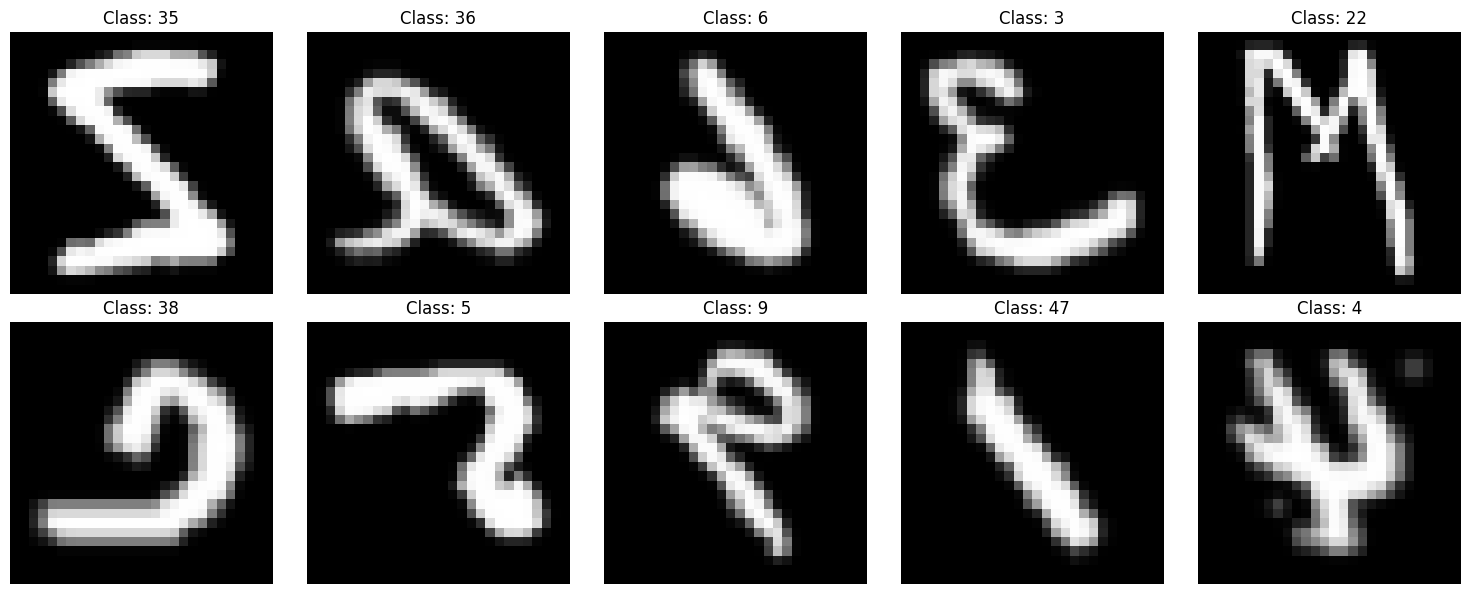


Dataset loaded successfully!


In [4]:
import pandas as pd
print("=" * 60)
print("EMNIST DATASET LOADING (CSV FORMAT)")
print("=" * 60)

# Load CSV files
emnist_train_path = "/kaggle/input/emnist/emnist-byclass-train.csv"
emnist_test_path = "/kaggle/input/emnist/emnist-byclass-test.csv"

print("Loading EMNIST train data...")
# CSV format: first column is label, remaining 784 columns are pixel values
train_df = pd.read_csv(emnist_train_path, header=None)
ye_train = train_df.iloc[:, 0].values.astype(np.int64)
Xe_train = train_df.iloc[:, 1:].values.astype(np.float32)

print("Loading EMNIST test data...")
test_df = pd.read_csv(emnist_test_path, header=None)
ye_test = test_df.iloc[:, 0].values.astype(np.int64)
Xe_test = test_df.iloc[:, 1:].values.astype(np.float32)

print(f"\nEMNIST train images shape: {Xe_train.shape}")
print(f"EMNIST test images shape: {Xe_test.shape}")
print(f"EMNIST train labels shape: {ye_train.shape}")
print(f"EMNIST test labels shape: {ye_test.shape}")
print(f"Number of classes in EMNIST: {len(np.unique(ye_train))}")

# Function to preprocess EMNIST images from CSV
def preprocess_emnist_csv(X):
    """
    Preprocess EMNIST images from CSV format
    CSV images are flattened 784 values (28x28)
    Need to reshape, transpose, and flip for correct orientation
    """
    # Reshape to 28x28
    X = X.reshape(-1, 28, 28)
    # Transpose and flip for correct orientation
    X = np.transpose(X, (0, 2, 1))
    X = np.flip(X, axis=2)
    # Normalize to [0, 1]
    return X.astype("float32") / 255.0

Xe_train = preprocess_emnist_csv(Xe_train)
Xe_test = preprocess_emnist_csv(Xe_test)

print(f"\nAfter preprocessing:")
print(f"Train shape: {Xe_train.shape}")
print(f"Test shape: {Xe_test.shape}")

# Visualize sample EMNIST images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(Xe_train[i], cmap='gray')
    axes[row, col].set_title(f"Class: {ye_train[i]}")
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

# Clear DataFrames to free memory
del train_df, test_df
print("\nDataset loaded successfully!")


In [ ]:
### 1.3 Data Preprocessing: Create Custom Dataset Classes


In [7]:
# Custom Dataset class for EMNIST
class EMNISTDataset(Dataset):
    """Custom dataset for EMNIST with label mapping"""
    def __init__(self, images, labels, transform=None, label_mapping=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        self.label_mapping = label_mapping
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        if self.label_mapping is not None:
            label = self.label_mapping[label]
        return img, label

# Transforms (CNN + EfficientNet)
transform_cnn_train = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((28, 28)),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_cnn_eval = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_effnet_train = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),
    transforms.RandomAffine(0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_effnet_eval = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined successfully!")


Transforms defined successfully!


In [ ]:
### 1.4 Create Unified Dataset Structure


In [6]:
# Create synthetic dataset with appropriate transform
# Create synthetic dataset (train + test combined)
synthetic_base_datasets = [
    remap_synthetic_to_binary(ImageFolder(synthetic_train_path, transform=transforms.ToTensor())),
    remap_synthetic_to_binary(ImageFolder(synthetic_test_path, transform=transforms.ToTensor())),
]
synthetic_ds_basic = ConcatDataset(synthetic_base_datasets)
synthetic_class_names = BINARY_CLASS_NAMES

# Create EMNIST datasets (mapped to class 0 = normal)
emnist_label_mapping = {i: 0 for i in range(62)}
emnist_train_ds = EMNISTDataset(Xe_train, ye_train, transform=transforms.ToTensor(), label_mapping=emnist_label_mapping)
emnist_test_ds = EMNISTDataset(Xe_test, ye_test, transform=transforms.ToTensor(), label_mapping=emnist_label_mapping)

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"Synthetic dataset: {len(synthetic_ds_basic)} samples")
print(f"EMNIST train: {len(emnist_train_ds)} samples")
print(f"EMNIST test: {len(emnist_test_ds)} samples")
print(f"\nTotal available for training: {len(synthetic_ds_basic) + len(emnist_train_ds)}")
print(f"Total available for testing: {len(emnist_test_ds)}")


DATASET STATISTICS
Synthetic dataset: 208372 samples
EMNIST train: 697932 samples
EMNIST test: 116323 samples

Total available for training: 906304
Total available for testing: 116323


In [ ]:
### 1.5 Split Data into Train/Validation/Test Sets


In [7]:
# Balanced synthetic test subset (10% per class)
synth_test_ratio = 0.10
if 'synthetic_base_datasets' not in globals():
    synthetic_base_datasets = [
        remap_synthetic_to_binary(ImageFolder(synthetic_train_path, transform=transforms.ToTensor())),
        remap_synthetic_to_binary(ImageFolder(synthetic_test_path, transform=transforms.ToTensor())),
    ]
    synthetic_ds_basic = ConcatDataset(synthetic_base_datasets)

class_to_indices = defaultdict(list)
offset = 0
for ds in synthetic_base_datasets:
    for rel_idx, (_, label) in enumerate(ds.samples):
        class_to_indices[label].append(offset + rel_idx)
    offset += len(ds)

balanced_test_indices = []
torch_gen = torch.Generator().manual_seed(SEED)
for label, idxs in class_to_indices.items():
    take = max(1, int(synth_test_ratio * len(idxs)))
    perm = torch.randperm(len(idxs), generator=torch_gen)
    balanced_test_indices.extend([idxs[i.item()] for i in perm[:take]])

balanced_test_indices = sorted(set(balanced_test_indices))
mask = torch.ones(len(synthetic_ds_basic), dtype=torch.bool)
mask[torch.tensor(balanced_test_indices, dtype=torch.long)] = False
remaining_indices = mask.nonzero(as_tuple=False).squeeze(1).tolist()

synthetic_test = Subset(synthetic_ds_basic, balanced_test_indices)
synthetic_remaining = Subset(synthetic_ds_basic, remaining_indices)
print(f"[Data] Synthetic test subset: {len(synthetic_test)} samples ({len(balanced_test_indices)/len(synthetic_ds_basic):.1%})")

# Split synthetic remainder into train/val (80/20)
synthetic_train_size = int(0.8 * len(synthetic_remaining))
synthetic_val_size = len(synthetic_remaining) - synthetic_train_size
synthetic_train, synthetic_val = random_split(
    synthetic_remaining,
    [synthetic_train_size, synthetic_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Subsample EMNIST train set to reduce imbalance
emnist_total = len(emnist_train_ds)
emnist_limit = int(EMNIST_TRAIN_FRACTION * emnist_total)
emnist_perm = torch.randperm(emnist_total, generator=torch.Generator().manual_seed(SEED))
if emnist_limit < emnist_total:
    emnist_subset = Subset(emnist_train_ds, emnist_perm[:emnist_limit])
else:
    emnist_subset = emnist_train_ds

emnist_train_size = int(0.8 * len(emnist_subset))
emnist_val_size = len(emnist_subset) - emnist_train_size
emnist_train_split, emnist_val_split = random_split(
    emnist_subset,
    [emnist_train_size, emnist_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Combine for final datasets
train_dataset = ConcatDataset([synthetic_train, emnist_train_split])
val_dataset = ConcatDataset([synthetic_val, emnist_val_split])
test_dataset = ConcatDataset([emnist_test_ds, synthetic_test])

print("=" * 60)
print("DATA SPLIT SUMMARY")
print("=" * 60)
print(f"Training set: {len(train_dataset)} samples")
print(f"  - Synthetic train: {len(synthetic_train)}")
print(f"  - EMNIST train: {len(emnist_train_split)}")
print(f"Validation set: {len(val_dataset)} samples")
print(f"  - Synthetic val: {len(synthetic_val)}")
print(f"  - EMNIST val: {len(emnist_val_split)}")
print(f"Test set: {len(test_dataset)} samples")
print(f"  - EMNIST test: {len(emnist_test_ds)}")
print(f"  - Synthetic test: {len(synthetic_test)}")

# Training class distribution snapshot
train_class_counts = {i: 0 for i in range(len(synthetic_class_names))}
for _, label in train_dataset:
    if label in train_class_counts:
        train_class_counts[label] += 1

print("\nTraining set class distribution:")
for class_idx, count in train_class_counts.items():
    class_name = synthetic_class_names[class_idx]
    print(f"  Class {class_idx} ({class_name}): {count}")


[Data] Synthetic test subset: 20837 samples (10.0%)
DATA SPLIT SUMMARY
Training set: 289614 samples
  - Synthetic train: 150028
  - EMNIST train: 139586
Validation set: 72404 samples
  - Synthetic val: 37507
  - EMNIST val: 34897
Test set: 137160 samples
  - EMNIST test: 116323
  - Synthetic test: 20837


/tmp/ipykernel_47/713535826.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')



Training set class distribution:
  Class 0 (Normal): 181985
  Class 1 (Dyslexia): 107629


In [ ]:
### 1.6 Create DataLoader Objects


In [33]:
# Wrapper class to apply transforms to datasets
class TransformDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    
        
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if isinstance(img, torch.Tensor):
            if img.dim() == 2:
                img = Image.fromarray((img.numpy() * 255).astype('uint8'), mode='L')
            elif img.dim() == 3:
                if img.shape[0] == 1:
                    img = Image.fromarray((img.squeeze(0).numpy() * 255).astype('uint8'), mode='L')
                elif img.shape[0] == 3:
                    img = Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype('uint8'), mode='RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# CNN datasets (28x28, grayscale)
train_ds_cnn = TransformDataset(train_dataset, transform_cnn_train)
val_ds_cnn = TransformDataset(val_dataset, transform_cnn_eval)
test_ds_cnn = TransformDataset(test_dataset, transform_cnn_eval)

# EfficientNet datasets (224x224, RGB)
train_ds_effnet = TransformDataset(train_dataset, transform_effnet_train)
val_ds_effnet = TransformDataset(val_dataset, transform_effnet_eval)
test_ds_effnet = TransformDataset(test_dataset, transform_effnet_eval)

batch_size = 64
num_workers = 0

train_loader_cnn = DataLoader(train_ds_cnn, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
val_loader_cnn = DataLoader(val_ds_cnn, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True)
test_loader_cnn = DataLoader(test_ds_cnn, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True)

train_loader_effnet = DataLoader(train_ds_effnet, batch_size=batch_size, shuffle=True,
                                 num_workers=num_workers, pin_memory=True)
val_loader_effnet = DataLoader(val_ds_effnet, batch_size=batch_size, shuffle=False,
                               num_workers=num_workers, pin_memory=True)
test_loader_effnet = DataLoader(test_ds_effnet, batch_size=batch_size, shuffle=False,
                                num_workers=num_workers, pin_memory=True)

print("=" * 60)
print("DATALOADERS READY")
print("=" * 60)
print(f"CNN -> Train: {len(train_loader_cnn)}, Val: {len(val_loader_cnn)}, Test: {len(test_loader_cnn)}")
print(f"EfficientNet -> Train: {len(train_loader_effnet)}, Val: {len(val_loader_effnet)}, Test: {len(test_loader_effnet)}")


DATALOADERS READY
CNN -> Train: 4526, Val: 1132, Test: 2144
EfficientNet -> Train: 4526, Val: 1132, Test: 2144


In [21]:
class CNNClassifier(nn.Module):
    """
    Custom CNN architecture for handwriting classification
    Input: 28x28 grayscale images
    Output: 3 classes (normal, reversed, corrected)
    """
    def __init__(self, num_classes=3):
        super(CNNClassifier, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        # Pooling and dropout
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        
        # Fully connected layers
        # After 3 pooling operations: 28 -> 14 -> 7 -> 3
        self.fc1 = nn.Linear(256 * 3 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Conv block 1
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        
        # Conv block 2
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        
        # Conv block 3
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        
        # Conv block 4
        x = self.relu(self.bn4(self.conv4(x)))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x

# Initialize CNN model
cnn_model = CNNClassifier(num_classes=3).to(device)

# Print model architecture
print("=" * 60)
print("CNN MODEL ARCHITECTURE")
print("=" * 60)
print(cnn_model)

# Count parameters
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Test forward pass
test_input = torch.randn(1, 1, 28, 28).to(device)
test_output = cnn_model(test_input)
print(f"\nTest input shape: {test_input.shape}")
print(f"Test output shape: {test_output.shape}")


CNN MODEL ARCHITECTURE
CNNClassifier(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2304, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_feat

### 2.3 Training Functions and Utilities


In [10]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train model for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """Validate model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels

def test_model(model, test_loader, criterion, device, class_names=None):
    """Test model and return detailed metrics"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_loss = running_loss / len(test_loader)
    test_acc = 100 * correct / total
    
    # Classification report
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(np.unique(all_labels)))]
    
    report = classification_report(all_labels, all_preds, target_names=class_names)
    cm = confusion_matrix(all_labels, all_preds)
    
    return test_loss, test_acc, all_preds, all_labels, report, cm

print("Training utilities defined successfully!")


Training utilities defined successfully!


### 2.4 Train CNN Model


In [ ]:
# Training configuration for CNN
cnn_epochs = 20
cnn_lr = 0.001
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=cnn_lr, weight_decay=1e-5)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(cnn_optimizer, mode='min', 
                                                      factor=0.5, patience=3, verbose=True)

# Training history
cnn_train_losses = []
cnn_train_accs = []
cnn_val_losses = []
cnn_val_accs = []
best_cnn_val_acc = 0.0
best_cnn_model_state = None

print("=" * 60)
print("TRAINING CNN MODEL")
print("=" * 60)
print(f"Epochs: {cnn_epochs}")
print(f"Learning rate: {cnn_lr}")
print(f"Batch size: {batch_size}")
print(f"Device: {device}")
print("=" * 60)

for epoch in range(cnn_epochs):
    # Train
    train_loss, train_acc = train_epoch(cnn_model, train_loader_cnn, cnn_criterion, 
                                        cnn_optimizer, device)
    
    # Validate
    val_loss, val_acc, _, _ = validate(cnn_model, val_loader_cnn, cnn_criterion, device)
    
    # Learning rate scheduling
    cnn_scheduler.step(val_loss)
    
    # Save history
    cnn_train_losses.append(train_loss)
    cnn_train_accs.append(train_acc)
    cnn_val_losses.append(val_loss)
    cnn_val_accs.append(val_acc)
    
    # Save best model
    if val_acc > best_cnn_val_acc:
        best_cnn_val_acc = val_acc
        best_cnn_model_state = cnn_model.state_dict().copy()
    
    # Print progress
    print(f"Epoch [{epoch+1}/{cnn_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print(f"  LR: {cnn_optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

# Load best model
cnn_model.load_state_dict(best_cnn_model_state)
print(f"\nBest validation accuracy: {best_cnn_val_acc:.2f}%")
print("CNN training completed!")


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_47/191229588.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype('uint8'), mode='RGB')
/tmp/ipykernel_47/713535826.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')
/tmp/ipykernel_47/191229588.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.squeeze(0).numpy() * 255).astype('uint8'), mode='L')


TRAINING CNN MODEL
Epochs: 20
Learning rate: 0.001
Batch size: 64
Device: cuda
Epoch [1/20]
  Train Loss: 0.1600, Train Acc: 93.77%
  Val Loss: 0.3304, Val Acc: 90.60%
  LR: 0.001000
------------------------------------------------------------
Epoch [2/20]
  Train Loss: 0.0792, Train Acc: 97.12%
  Val Loss: 0.0481, Val Acc: 98.08%
  LR: 0.001000
------------------------------------------------------------
Epoch [3/20]
  Train Loss: 0.0567, Train Acc: 97.97%
  Val Loss: 0.0377, Val Acc: 98.57%
  LR: 0.001000
------------------------------------------------------------
Epoch [4/20]
  Train Loss: 0.0460, Train Acc: 98.37%
  Val Loss: 0.0404, Val Acc: 98.48%
  LR: 0.001000
------------------------------------------------------------
Epoch [5/20]
  Train Loss: 0.0397, Train Acc: 98.61%
  Val Loss: 0.0301, Val Acc: 98.89%
  LR: 0.001000
------------------------------------------------------------
Epoch [6/20]
  Train Loss: 0.0349, Train Acc: 98.76%
  Val Loss: 0.0343, Val Acc: 98.78%
  LR: 0

### 2.5 Train EfficientNet-B0 Model


In [3]:
# Import necessary libraries
import os
import copy
from contextlib import nullcontext
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
from scipy.io import loadmat
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.backends.cudnn.benchmark = True  # allow cuDNN to pick fastest kernels

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# EfficientNet-B0 runtime controls for Kaggle sessions
CHECKPOINT_DIR = "/kaggle/working/effnet_checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "efficientnet_b0_state.pt")
RESUME_TRAINING = True  # set False to force a fresh start even if a checkpoint exists
DATASET_FRACTION = float(os.environ.get("EFFNET_DATASET_FRACTION", 0.35))  # 35% by default
DATASET_FRACTION = min(max(DATASET_FRACTION, 0.05), 1.0)  # clamp between 5% and 100%
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoint directory: {CHECKPOINT_DIR}")
print(f"Resume enabled: {RESUME_TRAINING}")
print(f"Train subset fraction: {DATASET_FRACTION:.2f}")


Using device: cuda
Checkpoint directory: /kaggle/working/effnet_checkpoints
Resume enabled: True
Train subset fraction: 0.35


SYNTHETIC DATASET EXPLORATION
Binary classes: ['Normal', 'Dyslexia'] (Normal vs Dyslexia)
Train samples: 151649 | Test samples: 56723
Total samples: 208372

Samples per class (train+test):
  Normal: 58891
  Dyslexia: 149481


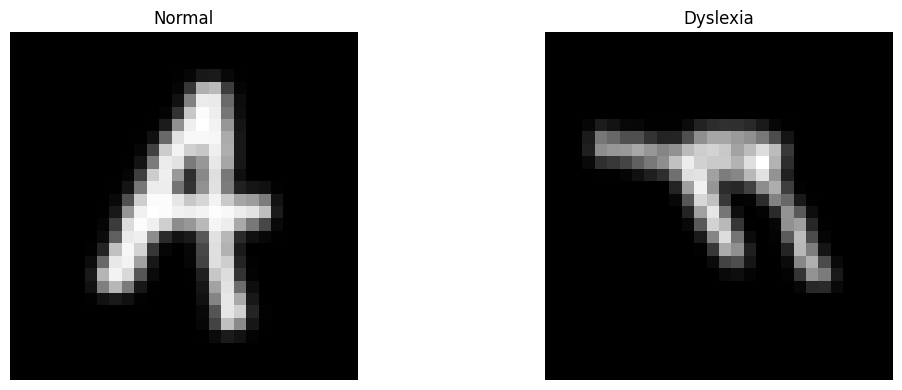

In [5]:
# Load synthetic dataset (normal, reversed, corrected)
synthetic_train_path = "/kaggle/input/dyslexia-dataset/Train"
synthetic_test_path = "/kaggle/input/dyslexia-dataset/Test"

basic_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

synthetic_train_raw = remap_synthetic_to_binary(ImageFolder(synthetic_train_path, transform=basic_transform))
synthetic_test_raw = remap_synthetic_to_binary(ImageFolder(synthetic_test_path, transform=basic_transform))
synthetic_dataset = ConcatDataset([synthetic_train_raw, synthetic_test_raw])
synthetic_class_names = BINARY_CLASS_NAMES
synthetic_dataset.classes = synthetic_class_names
synthetic_dataset.class_to_idx = {name: idx for idx, name in enumerate(synthetic_class_names)}

print("=" * 60)
print("SYNTHETIC DATASET EXPLORATION")
print("=" * 60)
print(f"Binary classes: {synthetic_class_names} (Normal vs Dyslexia)")
print(f"Train samples: {len(synthetic_train_raw)} | Test samples: {len(synthetic_test_raw)}")
print(f"Total samples: {len(synthetic_dataset)}")

class_counts = {name: 0 for name in synthetic_class_names}
for ds in [synthetic_train_raw, synthetic_test_raw]:
    for _, label in ds:
        class_counts[synthetic_class_names[label]] += 1

print("\nSamples per class (train+test):")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count}")

fig, axes = plt.subplots(1, len(synthetic_class_names), figsize=(12, 4))
for i, class_name in enumerate(synthetic_class_names):
    for img, label in synthetic_train_raw:
        if label == i:
            axes[i].imshow(img.squeeze(), cmap='gray')
            axes[i].set_title(class_name)
            axes[i].axis('off')
            break
plt.tight_layout()
plt.show()


EMNIST DATASET LOADING (CSV FORMAT)
Loading EMNIST train data...
Loading EMNIST test data...

EMNIST train images shape: (697932, 784)
EMNIST test images shape: (116323, 784)
EMNIST train labels shape: (697932,)
EMNIST test labels shape: (116323,)
Number of classes in EMNIST: 62

After preprocessing:
Train shape: (697932, 28, 28)
Test shape: (116323, 28, 28)


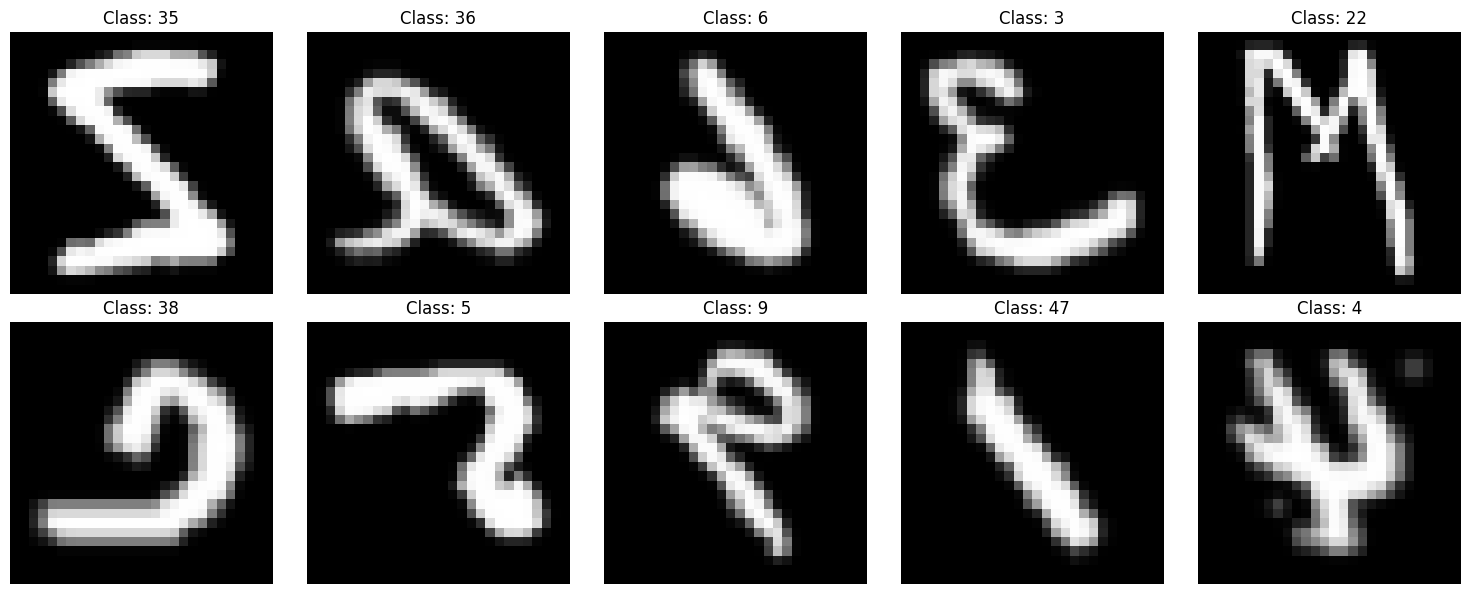


Dataset loaded successfully!


In [6]:
import pandas as pd
print("=" * 60)
print("EMNIST DATASET LOADING (CSV FORMAT)")
print("=" * 60)

# Load CSV files
emnist_train_path = "/kaggle/input/emnist/emnist-byclass-train.csv"
emnist_test_path = "/kaggle/input/emnist/emnist-byclass-test.csv"

print("Loading EMNIST train data...")
# CSV format: first column is label, remaining 784 columns are pixel values
train_df = pd.read_csv(emnist_train_path, header=None)
ye_train = train_df.iloc[:, 0].values.astype(np.int64)
Xe_train = train_df.iloc[:, 1:].values.astype(np.float32)

print("Loading EMNIST test data...")
test_df = pd.read_csv(emnist_test_path, header=None)
ye_test = test_df.iloc[:, 0].values.astype(np.int64)
Xe_test = test_df.iloc[:, 1:].values.astype(np.float32)

print(f"\nEMNIST train images shape: {Xe_train.shape}")
print(f"EMNIST test images shape: {Xe_test.shape}")
print(f"EMNIST train labels shape: {ye_train.shape}")
print(f"EMNIST test labels shape: {ye_test.shape}")
print(f"Number of classes in EMNIST: {len(np.unique(ye_train))}")

# Function to preprocess EMNIST images from CSV
def preprocess_emnist_csv(X):
    """
    Preprocess EMNIST images from CSV format
    CSV images are flattened 784 values (28x28)
    Need to reshape, transpose, and flip for correct orientation
    """
    # Reshape to 28x28
    X = X.reshape(-1, 28, 28)
    # Transpose and flip for correct orientation
    X = np.transpose(X, (0, 2, 1))
    X = np.flip(X, axis=2)
    # Normalize to [0, 1]
    return X.astype("float32") / 255.0

Xe_train = preprocess_emnist_csv(Xe_train)
Xe_test = preprocess_emnist_csv(Xe_test)

print(f"\nAfter preprocessing:")
print(f"Train shape: {Xe_train.shape}")
print(f"Test shape: {Xe_test.shape}")

# Visualize sample EMNIST images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(Xe_train[i], cmap='gray')
    axes[row, col].set_title(f"Class: {ye_train[i]}")
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

# Clear DataFrames to free memory
del train_df, test_df
print("\nDataset loaded successfully!")


In [8]:
# Custom Dataset class for EMNIST
class EMNISTDataset(Dataset):
    """Custom dataset for EMNIST with label mapping"""
    def __init__(self, images, labels, transform=None, label_mapping=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        self.label_mapping = label_mapping
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        if self.label_mapping is not None:
            label = self.label_mapping[label]
        return img, label

# Transforms (CNN + EfficientNet)
transform_cnn_train = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((28, 28)),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_cnn_eval = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_effnet_train = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),
    transforms.RandomAffine(0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_effnet_eval = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined successfully!")


Transforms defined successfully!


In [9]:
# Create synthetic dataset with appropriate transform
# Create synthetic dataset (train + test combined)
synthetic_base_datasets = [
    remap_synthetic_to_binary(ImageFolder(synthetic_train_path, transform=transforms.ToTensor())),
    remap_synthetic_to_binary(ImageFolder(synthetic_test_path, transform=transforms.ToTensor())),
]
synthetic_ds_basic = ConcatDataset(synthetic_base_datasets)
synthetic_class_names = BINARY_CLASS_NAMES

# Create EMNIST datasets (mapped to class 0 = normal)
emnist_label_mapping = {i: 0 for i in range(62)}
emnist_train_ds = EMNISTDataset(Xe_train, ye_train, transform=transforms.ToTensor(), label_mapping=emnist_label_mapping)
emnist_test_ds = EMNISTDataset(Xe_test, ye_test, transform=transforms.ToTensor(), label_mapping=emnist_label_mapping)

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"Synthetic dataset: {len(synthetic_ds_basic)} samples")
print(f"EMNIST train: {len(emnist_train_ds)} samples")
print(f"EMNIST test: {len(emnist_test_ds)} samples")
print(f"\nTotal available for training: {len(synthetic_ds_basic) + len(emnist_train_ds)}")
print(f"Total available for testing: {len(emnist_test_ds)}")


DATASET STATISTICS
Synthetic dataset: 208372 samples
EMNIST train: 697932 samples
EMNIST test: 116323 samples

Total available for training: 906304
Total available for testing: 116323


In [10]:
# Balanced synthetic test subset (10% per class)
synth_test_ratio = 0.10
if 'synthetic_base_datasets' not in globals():
    synthetic_base_datasets = [
        remap_synthetic_to_binary(ImageFolder(synthetic_train_path, transform=transforms.ToTensor())),
        remap_synthetic_to_binary(ImageFolder(synthetic_test_path, transform=transforms.ToTensor())),
    ]
    synthetic_ds_basic = ConcatDataset(synthetic_base_datasets)

class_to_indices = defaultdict(list)
offset = 0
for ds in synthetic_base_datasets:
    for rel_idx, (_, label) in enumerate(ds.samples):
        class_to_indices[label].append(offset + rel_idx)
    offset += len(ds)

balanced_test_indices = []
torch_gen = torch.Generator().manual_seed(SEED)
for label, idxs in class_to_indices.items():
    take = max(1, int(synth_test_ratio * len(idxs)))
    perm = torch.randperm(len(idxs), generator=torch_gen)
    balanced_test_indices.extend([idxs[i.item()] for i in perm[:take]])

balanced_test_indices = sorted(set(balanced_test_indices))
mask = torch.ones(len(synthetic_ds_basic), dtype=torch.bool)
mask[torch.tensor(balanced_test_indices, dtype=torch.long)] = False
remaining_indices = mask.nonzero(as_tuple=False).squeeze(1).tolist()

synthetic_test = Subset(synthetic_ds_basic, balanced_test_indices)
synthetic_remaining = Subset(synthetic_ds_basic, remaining_indices)
print(f"[Data] Synthetic test subset: {len(synthetic_test)} samples ({len(balanced_test_indices)/len(synthetic_ds_basic):.1%})")

# Split synthetic remainder into train/val (80/20)
synthetic_train_size = int(0.8 * len(synthetic_remaining))
synthetic_val_size = len(synthetic_remaining) - synthetic_train_size
synthetic_train, synthetic_val = random_split(
    synthetic_remaining,
    [synthetic_train_size, synthetic_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Subsample EMNIST train set to reduce imbalance
emnist_total = len(emnist_train_ds)
emnist_limit = int(EMNIST_TRAIN_FRACTION * emnist_total)
emnist_perm = torch.randperm(emnist_total, generator=torch.Generator().manual_seed(SEED))
if emnist_limit < emnist_total:
    emnist_subset = Subset(emnist_train_ds, emnist_perm[:emnist_limit])
else:
    emnist_subset = emnist_train_ds

emnist_train_size = int(0.8 * len(emnist_subset))
emnist_val_size = len(emnist_subset) - emnist_train_size
emnist_train_split, emnist_val_split = random_split(
    emnist_subset,
    [emnist_train_size, emnist_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Combine for final datasets
train_dataset = ConcatDataset([synthetic_train, emnist_train_split])
val_dataset = ConcatDataset([synthetic_val, emnist_val_split])
test_dataset = ConcatDataset([emnist_test_ds, synthetic_test])

print("=" * 60)
print("DATA SPLIT SUMMARY")
print("=" * 60)
print(f"Training set: {len(train_dataset)} samples")
print(f"  - Synthetic train: {len(synthetic_train)}")
print(f"  - EMNIST train: {len(emnist_train_split)}")
print(f"Validation set: {len(val_dataset)} samples")
print(f"  - Synthetic val: {len(synthetic_val)}")
print(f"  - EMNIST val: {len(emnist_val_split)}")
print(f"Test set: {len(test_dataset)} samples")
print(f"  - EMNIST test: {len(emnist_test_ds)}")
print(f"  - Synthetic test: {len(synthetic_test)}")

# Training class distribution snapshot
train_class_counts = {i: 0 for i in range(len(synthetic_class_names))}
for _, label in train_dataset:
    if label in train_class_counts:
        train_class_counts[label] += 1

print("\nTraining set class distribution:")
for class_idx, count in train_class_counts.items():
    class_name = synthetic_class_names[class_idx]
    print(f"  Class {class_idx} ({class_name}): {count}")


[Data] Synthetic test subset: 20837 samples (10.0%)
DATA SPLIT SUMMARY
Training set: 289614 samples
  - Synthetic train: 150028
  - EMNIST train: 139586
Validation set: 72404 samples
  - Synthetic val: 37507
  - EMNIST val: 34897
Test set: 137160 samples
  - EMNIST test: 116323
  - Synthetic test: 20837


/tmp/ipykernel_47/713535826.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')



Training set class distribution:
  Class 0 (Normal): 181985
  Class 1 (Dyslexia): 107629


In [11]:
# Wrapper class to apply transforms to datasets
class TransformDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if isinstance(img, torch.Tensor):
            # Convert tensor to PIL Image if needed
            if img.dim() == 2:
                # Grayscale 2D tensor (H, W)
                img = Image.fromarray((img.numpy() * 255).astype('uint8'), mode='L')
            elif img.dim() == 3:
                # 3D tensor (C, H, W)
                if img.shape[0] == 1:
                    # Single channel - grayscale
                    img = Image.fromarray((img.squeeze(0).numpy() * 255).astype('uint8'), mode='L')
                elif img.shape[0] == 3:
                    # Three channels - RGB
                    img = Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype('uint8'), mode='RGB')
        
        if self.transform:
            img = self.transform(img)
        return img, label
# For EfficientNet-B0 (224x224, 3 channels)
train_ds_effnet = TransformDataset(train_dataset, transform_effnet_train)
val_ds_effnet = TransformDataset(val_dataset, transform_effnet_eval)
test_ds_effnet = TransformDataset(test_dataset, transform_effnet_eval)

# Create DataLoaders
batch_size = 64
num_workers = 0  # Set to 0 for Kaggle to avoid multiprocessing issues
# EfficientNet-B0 DataLoaders
train_loader_effnet = DataLoader(train_ds_effnet, batch_size=batch_size, shuffle=True,
                                 num_workers=num_workers, pin_memory=True)
val_loader_effnet = DataLoader(val_ds_effnet, batch_size=batch_size, shuffle=False,
                               num_workers=num_workers, pin_memory=True)
test_loader_effnet = DataLoader(test_ds_effnet, batch_size=batch_size, shuffle=False,
                                num_workers=num_workers, pin_memory=True)
print("=" * 60)
print("DATALOADERS CREATED")
print("=" * 60)
print(f"\nEfficientNet-B0 DataLoaders:")
print(f"  Train batches: {len(train_loader_effnet)}")
print(f"  Val batches: {len(val_loader_effnet)}")
print(f"  Test batches: {len(test_loader_effnet)}")

DATALOADERS CREATED

EfficientNet-B0 DataLoaders:
  Train batches: 4526
  Val batches: 1132
  Test batches: 2144


In [12]:
def create_efficientnet_b0_model(num_classes=3, pretrained=True):
    """Create EfficientNet-B0 model for handwriting classification."""
    weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

def set_effnet_backbone_trainable(model, train_backbone=False):
    """Freeze/unfreeze EfficientNet backbone while keeping classifier trainable."""
    for name, param in model.named_parameters():
        if name.startswith("classifier"):
            param.requires_grad = True
        else:
            param.requires_grad = train_backbone

# Initialize EfficientNet-B0 model
num_target_classes = len(synthetic_class_names)
effnet_model = create_efficientnet_b0_model(num_classes=num_target_classes, pretrained=True).to(device)
set_effnet_backbone_trainable(effnet_model, train_backbone=False)  # Start with frozen backbone

print("=" * 60)
print("EFFICIENTNET-B0 MODEL (BACKBONE FROZEN)")
print("=" * 60)
print(effnet_model)

# Count parameters
total_params = sum(p.numel() for p in effnet_model.parameters())
trainable_params = sum(p.numel() for p in effnet_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters (head-only): {trainable_params:,}")

# Test forward pass
test_input = torch.randn(1, 3, 224, 224).to(device)
test_output = effnet_model(test_input)
print(f"\nTest input shape: {test_input.shape}")
print(f"Test output shape: {test_output.shape}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 167MB/s]


EFFICIENTNET-B0 MODEL (BACKBONE FROZEN)
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
    

In [13]:
def train_epoch(model, train_loader, criterion, optimizer, device, use_amp=False, scaler=None):
    """Train model for one epoch with optional mixed precision."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        autocast_ctx = torch.amp.autocast('cuda', enabled=use_amp) if use_amp else nullcontext()
        with autocast_ctx:
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        if use_amp:
            if scaler is None:
                raise ValueError("GradScaler is required when use_amp=True")
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device, use_amp=False):
    """Validate model with optional mixed precision."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            autocast_ctx = torch.amp.autocast('cuda', enabled=use_amp) if use_amp else nullcontext()
            with autocast_ctx:
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels

def test_model(model, test_loader, criterion, device, class_names=None, use_amp=False, label_ids=None):
    """Test model and return detailed metrics."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            autocast_ctx = torch.amp.autocast('cuda', enabled=use_amp) if use_amp else nullcontext()
            with autocast_ctx:
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_loss = running_loss / len(test_loader)
    test_acc = 100 * correct / total
    
    if label_ids is None:
        label_ids = sorted(np.unique(all_labels))
    if class_names is None:
        class_names = [f"Class {lbl}" for lbl in label_ids]
    if len(class_names) != len(label_ids):
        raise ValueError("class_names and label_ids must have the same length")
    
    report = classification_report(
        all_labels,
        all_preds,
        labels=label_ids,
        target_names=class_names,
        zero_division=0,
    )
    cm = confusion_matrix(all_labels, all_preds, labels=label_ids)
    
    return test_loss, test_acc, all_preds, all_labels, report, cm

print("Training utilities defined successfully!")


Training utilities defined successfully!


In [14]:
def load_effnet_checkpoint(path: str = CHECKPOINT_PATH, map_location=device):
    """Load EfficientNet checkpoint if resume is enabled and file exists."""
    if not (RESUME_TRAINING and os.path.exists(path)):
        return None
    checkpoint = torch.load(path, map_location=map_location)
    print(
        f"[Checkpoint] Loaded state ({checkpoint.get('phase', 'unknown')}) "
        f"head_epoch={checkpoint.get('head_epoch', 0)} full_epoch={checkpoint.get('full_epoch', 0)}"
    )
    return checkpoint


def save_effnet_checkpoint(
    phase: str,
    head_epoch: int,
    full_epoch: int,
    model: nn.Module,
    best_state: dict,
    best_val_acc: float,
    history: dict,
    path: str = CHECKPOINT_PATH,
    head_optimizer: optim.Optimizer | None = None,
    head_scheduler: optim.lr_scheduler.ReduceLROnPlateau | None = None,
    finetune_optimizer: optim.Optimizer | None = None,
    finetune_scheduler: optim.lr_scheduler.ReduceLROnPlateau | None = None,
    head_scaler: torch.cuda.amp.GradScaler | None = None,
    finetune_scaler: torch.cuda.amp.GradScaler | None = None,
):
    """Persist EfficientNet training state so Kaggle crashes can resume.
    Saves to a temporary file first to avoid corrupt checkpoints when sessions stop abruptly.
    """
    if path is None:
        return

    state = {
        'phase': phase,
        'head_epoch': head_epoch,
        'full_epoch': full_epoch,
        'model_state_dict': model.state_dict(),
        'best_model_state_dict': best_state,
        'best_val_acc': best_val_acc,
        'history': history,
    }

    if head_optimizer is not None:
        state['head_optimizer_state'] = head_optimizer.state_dict()
    if head_scheduler is not None:
        state['head_scheduler_state'] = head_scheduler.state_dict()
    if finetune_optimizer is not None:
        state['finetune_optimizer_state'] = finetune_optimizer.state_dict()
    if finetune_scheduler is not None:
        state['finetune_scheduler_state'] = finetune_scheduler.state_dict()
    if head_scaler is not None:
        state['head_scaler_state'] = head_scaler.state_dict()
    if finetune_scaler is not None:
        state['finetune_scaler_state'] = finetune_scaler.state_dict()

    tmp_path = path + ".tmp"
    torch.save(state, tmp_path)
    os.replace(tmp_path, path)
    print(f"[Checkpoint] Saved EfficientNet state ({phase}) -> {path}")



In [15]:
# Training configuration for EfficientNet-B0
head_epochs = 3
finetune_epochs = 10
head_lr = 1e-3
finetune_lr = 5e-5
weight_decay = 1e-4

effnet_criterion = nn.CrossEntropyLoss()

# History containers (populated from checkpoint if available)
effnet_train_losses = []
effnet_val_losses = []
effnet_train_accs = []
effnet_val_accs = []
effnet_phase_labels = []

best_effnet_val_acc = 0.0
best_effnet_model_state = copy.deepcopy(effnet_model.state_dict())

checkpoint_state = load_effnet_checkpoint()
head_start_epoch = 0
full_start_epoch = 0
saved_head_opt_state = None
saved_head_sched_state = None
saved_full_opt_state = None
saved_full_sched_state = None
saved_head_scaler_state = None
saved_full_scaler_state = None
amp_enabled = device.type == 'cuda'

if checkpoint_state:
    effnet_model.load_state_dict(checkpoint_state.get('model_state_dict', effnet_model.state_dict()))
    best_effnet_model_state = checkpoint_state.get('best_model_state_dict', best_effnet_model_state)
    best_effnet_val_acc = checkpoint_state.get('best_val_acc', best_effnet_val_acc)
    history_state = checkpoint_state.get('history', {})
    effnet_train_losses = history_state.get('train_losses', effnet_train_losses)
    effnet_val_losses = history_state.get('val_losses', effnet_val_losses)
    effnet_train_accs = history_state.get('train_accs', effnet_train_accs)
    effnet_val_accs = history_state.get('val_accs', effnet_val_accs)
    effnet_phase_labels = history_state.get('phase_labels', effnet_phase_labels)
    head_start_epoch = checkpoint_state.get('head_epoch', 0)
    full_start_epoch = checkpoint_state.get('full_epoch', 0)
    saved_head_opt_state = checkpoint_state.get('head_optimizer_state')
    saved_head_sched_state = checkpoint_state.get('head_scheduler_state')
    saved_full_opt_state = checkpoint_state.get('finetune_optimizer_state')
    saved_full_sched_state = checkpoint_state.get('finetune_scheduler_state')
    saved_head_scaler_state = checkpoint_state.get('head_scaler_state')
    saved_full_scaler_state = checkpoint_state.get('finetune_scaler_state')

history_refs = {
    'train_losses': effnet_train_losses,
    'val_losses': effnet_val_losses,
    'train_accs': effnet_train_accs,
    'val_accs': effnet_val_accs,
    'phase_labels': effnet_phase_labels,
}

print("=" * 60)
print("TRAINING EFFICIENTNET-B0 MODEL")
print("=" * 60)
print(f"Head warm-up epochs: {head_epochs} @ lr={head_lr}")
print(f"Full fine-tune epochs: {finetune_epochs} @ lr={finetune_lr}")
print(f"Batch size: {batch_size}")
print(f"Device: {device}")
if checkpoint_state:
    print(f"Resuming from checkpoint -> head epoch {head_start_epoch}/{head_epochs}, full epoch {full_start_epoch}/{finetune_epochs}")
else:
    print("Starting EfficientNet training from scratch")
print("=" * 60)


def log_effnet_history(label, train_loss, train_acc, val_loss, val_acc):
    effnet_phase_labels.append(label)
    effnet_train_losses.append(train_loss)
    effnet_val_losses.append(val_loss)
    effnet_train_accs.append(train_acc)
    effnet_val_accs.append(val_acc)


# Phase 1: Warm-up classifier head (backbone frozen)
if head_start_epoch < head_epochs:
    print("\n--- Head Warm-up ---")
    set_effnet_backbone_trainable(effnet_model, train_backbone=False)
    head_optimizer = optim.Adam(filter(lambda p: p.requires_grad, effnet_model.parameters()),
                                lr=head_lr, weight_decay=weight_decay)
    head_scheduler = optim.lr_scheduler.ReduceLROnPlateau(head_optimizer, mode='min',
                                                          factor=0.5, patience=2, verbose=True)
    if saved_head_opt_state:
        head_optimizer.load_state_dict(saved_head_opt_state)
    if saved_head_sched_state:
        head_scheduler.load_state_dict(saved_head_sched_state)
    head_scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)
    if saved_head_scaler_state:
        head_scaler.load_state_dict(saved_head_scaler_state)

    for epoch in range(head_start_epoch, head_epochs):
        train_loss, train_acc = train_epoch(
            effnet_model,
            train_loader_effnet,
            effnet_criterion,
            head_optimizer,
            device,
            use_amp=amp_enabled,
            scaler=head_scaler,
        )
        val_loss, val_acc, _, _ = validate(
            effnet_model,
            val_loader_effnet,
            effnet_criterion,
            device,
            use_amp=amp_enabled,
        )
        head_scheduler.step(val_loss)
        log_effnet_history(f"head-{epoch+1}", train_loss, train_acc, val_loss, val_acc)

        if val_acc > best_effnet_val_acc:
            best_effnet_val_acc = val_acc
            best_effnet_model_state = copy.deepcopy(effnet_model.state_dict())

        save_effnet_checkpoint(
            phase='head',
            head_epoch=epoch + 1,
            full_epoch=full_start_epoch,
            model=effnet_model,
            best_state=best_effnet_model_state,
            best_val_acc=best_effnet_val_acc,
            history=history_refs,
            head_optimizer=head_optimizer,
            head_scheduler=head_scheduler,
            head_scaler=head_scaler,
        )

        print(f"Head Epoch [{epoch+1}/{head_epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print(f"  LR: {head_optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 60)

    head_start_epoch = head_epochs
else:
    print("\n--- Head Warm-up --- (skipped, already completed)")

# Phase 2: Full-model fine-tuning
set_effnet_backbone_trainable(effnet_model, train_backbone=True)
if full_start_epoch == 0:
    effnet_model.load_state_dict(best_effnet_model_state)

finetune_optimizer = optim.Adam(effnet_model.parameters(), lr=finetune_lr, weight_decay=weight_decay)
finetune_scheduler = optim.lr_scheduler.ReduceLROnPlateau(finetune_optimizer, mode='min',
                                                          factor=0.5, patience=2, verbose=True)
if saved_full_opt_state:
    finetune_optimizer.load_state_dict(saved_full_opt_state)
if saved_full_sched_state:
    finetune_scheduler.load_state_dict(saved_full_sched_state)
finetune_scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)
if saved_full_scaler_state:
    finetune_scaler.load_state_dict(saved_full_scaler_state)

print("\n--- Full Fine-tune ---")
if full_start_epoch < finetune_epochs:
    for epoch in range(full_start_epoch, finetune_epochs):
        train_loss, train_acc = train_epoch(
            effnet_model,
            train_loader_effnet,
            effnet_criterion,
            finetune_optimizer,
            device,
            use_amp=amp_enabled,
            scaler=finetune_scaler,
        )
        val_loss, val_acc, _, _ = validate(
            effnet_model,
            val_loader_effnet,
            effnet_criterion,
            device,
            use_amp=amp_enabled,
        )
        finetune_scheduler.step(val_loss)
        log_effnet_history(f"full-{epoch+1}", train_loss, train_acc, val_loss, val_acc)

        if val_acc > best_effnet_val_acc:
            best_effnet_val_acc = val_acc
            best_effnet_model_state = copy.deepcopy(effnet_model.state_dict())

        save_effnet_checkpoint(
            phase='full',
            head_epoch=head_start_epoch,
            full_epoch=epoch + 1,
            model=effnet_model,
            best_state=best_effnet_model_state,
            best_val_acc=best_effnet_val_acc,
            history=history_refs,
            finetune_optimizer=finetune_optimizer,
            finetune_scheduler=finetune_scheduler,
            finetune_scaler=finetune_scaler,
        )

        print(f"Full Epoch [{epoch+1}/{finetune_epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print(f"  LR: {finetune_optimizer.param_groups[0]['lr']:.6f}")
        print("-" * 60)
else:
    print("Skipping full fine-tune (already completed in checkpoint)")

# Load best weights across both phases
effnet_model.load_state_dict(best_effnet_model_state)
print(f"\nBest EfficientNet-B0 validation accuracy: {best_effnet_val_acc:.2f}%")
print("EfficientNet-B0 training completed!")

# Clean up checkpoint once training is done so the next run can start fresh
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print(f"[Checkpoint] Removed stale file: {CHECKPOINT_PATH}")


TRAINING EFFICIENTNET-B0 MODEL
Head warm-up epochs: 3 @ lr=0.001
Full fine-tune epochs: 10 @ lr=5e-05
Batch size: 64
Device: cuda
Starting EfficientNet training from scratch

--- Head Warm-up ---


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_47/713535826.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')
/tmp/ipykernel_47/1271053093.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.squeeze(0).numpy() * 255).astype('uint8'), mode='L')
/tmp/ipykernel_47/1271053093.py:24: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype('uint8'), mode='RGB')


[Checkpoint] Saved EfficientNet state (head) -> /kaggle/working/effnet_checkpoints/efficientnet_b0_state.pt
Head Epoch [1/3]
  Train Loss: 0.1943, Train Acc: 90.72%
  Val Loss: 0.1533, Val Acc: 92.47%
  LR: 0.001000
------------------------------------------------------------
[Checkpoint] Saved EfficientNet state (head) -> /kaggle/working/effnet_checkpoints/efficientnet_b0_state.pt
Head Epoch [2/3]
  Train Loss: 0.1884, Train Acc: 91.13%
  Val Loss: 0.1596, Val Acc: 92.62%
  LR: 0.001000
------------------------------------------------------------
[Checkpoint] Saved EfficientNet state (head) -> /kaggle/working/effnet_checkpoints/efficientnet_b0_state.pt
Head Epoch [3/3]
  Train Loss: 0.1879, Train Acc: 91.11%
  Val Loss: 0.1523, Val Acc: 92.77%
  LR: 0.001000
------------------------------------------------------------

--- Full Fine-tune ---
[Checkpoint] Saved EfficientNet state (full) -> /kaggle/working/effnet_checkpoints/efficientnet_b0_state.pt
Full Epoch [1/10]
  Train Loss: 0.064

### 2.6 Model Checkpointing


In [ ]:
# Save trained models (using Kaggle working directory)
model_save_dir = "/kaggle/working/models"
os.makedirs(model_save_dir, exist_ok=True)

# Save CNN model
cnn_model_path = os.path.join(model_save_dir, "cnn_classifier.pth")
torch.save({
    'model_state_dict': cnn_model.state_dict(),
    'optimizer_state_dict': cnn_optimizer.state_dict(),
    'epoch': cnn_epochs,
    'val_acc': best_cnn_val_acc,
    'train_losses': cnn_train_losses,
    'train_accs': cnn_train_accs,
    'val_losses': cnn_val_losses,
    'val_accs': cnn_val_accs,
}, cnn_model_path)
print(f"CNN model saved to {cnn_model_path}")


In [17]:
model_save_dir = "/kaggle/working/models"
os.makedirs(model_save_dir, exist_ok=True)
effnet_model_path = os.path.join(model_save_dir, "efficientnet_b0_classifier.pth")
torch.save({
    'model_state_dict': effnet_model.state_dict(),
    'head_epochs': head_epochs,
    'finetune_epochs': finetune_epochs,
    'val_acc': best_effnet_val_acc,
    'phase_labels': effnet_phase_labels,
    'train_losses': effnet_train_losses,
    'train_accs': effnet_train_accs,
    'val_losses': effnet_val_losses,
    'val_accs': effnet_val_accs,
}, effnet_model_path)
print(f"EfficientNet-B0 model saved to {effnet_model_path}")

print("\nModel checkpointing completed!")


EfficientNet-B0 model saved to /kaggle/working/models/efficientnet_b0_classifier.pth

Model checkpointing completed!


### 2.7 Testing/Evaluation


In [19]:
class_labels = list(range(len(synthetic_dataset.classes)))

In [23]:
checkpoint = torch.load("/kaggle/input/cnn-classifier-pth/other/default/1/cnn_classifier (2).pth", map_location=device)
cnn_model.load_state_dict(checkpoint["model_state_dict"])
cnn_model.to(device).eval()

CNNClassifier(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2304, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=3, bias=True)
  (r

In [45]:
# Test CNN model
print("=" * 60)
print("TESTING CNN MODEL")
print("=" * 60)
class_labels = list(range(len(synthetic_dataset.classes)))
cnn_test_loss, cnn_test_acc, cnn_preds, cnn_labels, cnn_report, cnn_cm = test_model(
    cnn_model,
    test_loader_cnn,
    cnn_criterion,
    device,
    class_names=synthetic_dataset.classes,
    #label_ids=class_labels,
)

print(f"Test Loss: {cnn_test_loss:.4f}")
print(f"Test Accuracy: {cnn_test_acc:.2f}%")
print("\nClassification Report:")
print(cnn_report)

TESTING CNN MODEL


/tmp/ipykernel_47/713535826.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')
/tmp/ipykernel_47/191229588.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.squeeze(0).numpy() * 255).astype('uint8'), mode='L')
/tmp/ipykernel_47/191229588.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype('uint8'), mode='RGB')


Test Loss: 0.0111
Test Accuracy: 99.67%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    122212
    Dyslexia       0.99      0.98      0.98     14948

    accuracy                           1.00    137160
   macro avg       0.99      0.99      0.99    137160
weighted avg       1.00      1.00      1.00    137160



In [20]:

# Test EfficientNet-B0 model
print("\n" + "=" * 60)
print("TESTING EFFICIENTNET-B0 MODEL")
print("=" * 60)
effnet_test_loss, effnet_test_acc, effnet_preds, effnet_labels, effnet_report, effnet_cm = test_model(
    effnet_model,
    test_loader_effnet,
    effnet_criterion,
    device,
    class_names=synthetic_dataset.classes,
    use_amp=amp_enabled,
    label_ids=class_labels,
)

print(f"Test Loss: {effnet_test_loss:.4f}")
print(f"Test Accuracy: {effnet_test_acc:.2f}%")
print("\nClassification Report:")
print(effnet_report)



TESTING EFFICIENTNET-B0 MODEL


/tmp/ipykernel_47/713535826.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')
/tmp/ipykernel_47/1271053093.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.squeeze(0).numpy() * 255).astype('uint8'), mode='L')
/tmp/ipykernel_47/1271053093.py:24: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype('uint8'), mode='RGB')


Test Loss: 0.0045
Test Accuracy: 99.85%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    122212
    Dyslexia       1.00      0.99      0.99     14948

    accuracy                           1.00    137160
   macro avg       1.00      0.99      1.00    137160
weighted avg       1.00      1.00      1.00    137160



/tmp/ipykernel_47/713535826.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')
/tmp/ipykernel_47/191229588.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.squeeze(0).numpy() * 255).astype('uint8'), mode='L')
/tmp/ipykernel_47/191229588.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype('uint8'), mode='RGB')


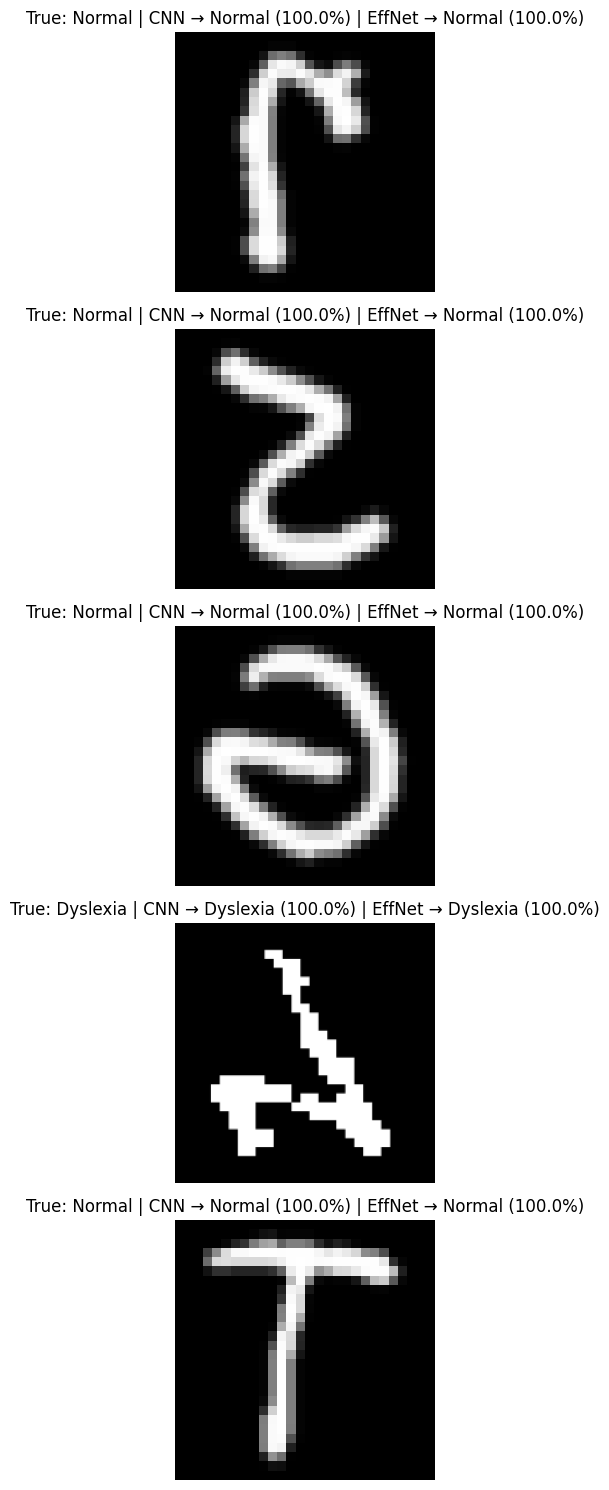

In [36]:
import random


def _to_display_array(img):
    if isinstance(img, torch.Tensor):
        arr = img.detach().cpu()
        if arr.dim() == 3 and arr.shape[0] in (1, 3):
            arr = arr.permute(1, 2, 0)
        if arr.dim() == 3 and arr.shape[2] == 1:
            arr = arr.squeeze(2)
        return arr.numpy()
    return np.array(img)


def preview_random_predictions(num_samples: int = 5):
    """Display random test samples with CNN/EfficientNet predictions."""
    assert num_samples > 0, "num_samples must be positive"
    cnn_model.eval()
    effnet_available = 'effnet_model' in globals()
    if effnet_available:
        effnet_model.eval()

    indices = random.sample(range(len(test_dataset)), k=min(num_samples, len(test_dataset)))

    fig, axes = plt.subplots(len(indices), 1, figsize=(6, 3 * len(indices)))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        raw_img, label = test_dataset[idx]
        label_name = synthetic_class_names[label]

        cnn_input, _ = test_ds_cnn[idx]
        with torch.no_grad():
            cnn_logits = cnn_model(cnn_input.unsqueeze(0).to(device))
            cnn_probs = torch.softmax(cnn_logits, dim=1).cpu().numpy().squeeze()
            cnn_pred = int(cnn_probs.argmax())

        effnet_pred = None
        effnet_conf = None
        if effnet_available:
            effnet_input, _ = test_ds_effnet[idx]
            with torch.no_grad():
                eff_logits = effnet_model(effnet_input.unsqueeze(0).to(device))
                eff_probs = torch.softmax(eff_logits, dim=1).cpu().numpy().squeeze()
                effnet_pred = int(eff_probs.argmax())
                effnet_conf = eff_probs[effnet_pred]

        ax.imshow(_to_display_array(raw_img), cmap='gray')
        ax.axis('off')
        cnn_line = f"CNN → {synthetic_class_names[cnn_pred]} ({cnn_probs[cnn_pred]*100:.1f}%)"
        eff_line = ""
        if effnet_available:
            eff_line = f" | EffNet → {synthetic_class_names[effnet_pred]} ({effnet_conf*100:.1f}%)"
        ax.set_title(f"True: {label_name} | {cnn_line}{eff_line}")

    plt.tight_layout()
    plt.show()


preview_random_predictions(num_samples=5)

/tmp/ipykernel_47/191229588.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype('uint8'), mode='RGB')
/tmp/ipykernel_47/713535826.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')
/tmp/ipykernel_47/191229588.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.squeeze(0).numpy() * 255).astype('uint8'), mode='L')


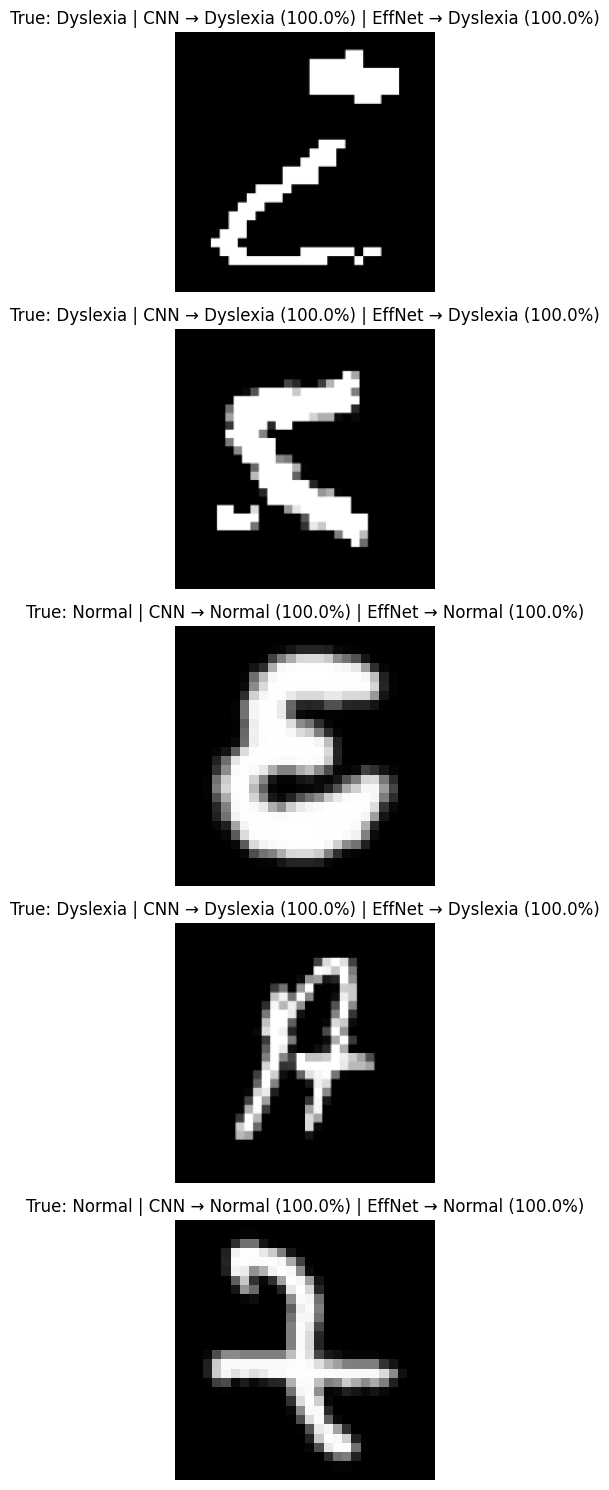

In [37]:
import random


def _to_display_array(img):
    if isinstance(img, torch.Tensor):
        arr = img.detach().cpu()
        if arr.dim() == 3 and arr.shape[0] in (1, 3):
            arr = arr.permute(1, 2, 0)
        if arr.dim() == 3 and arr.shape[2] == 1:
            arr = arr.squeeze(2)
        return arr.numpy()
    return np.array(img)


def preview_random_predictions(num_samples: int = 5, label_filter: int | None = None):
    """Display random test samples with CNN/EfficientNet predictions."""
    assert num_samples > 0, "num_samples must be positive"
    cnn_model.eval()
    effnet_available = 'effnet_model' in globals()
    if effnet_available:
        effnet_model.eval()

    candidate_indices = range(len(test_dataset))
    if label_filter is not None:
        candidate_indices = [i for i in candidate_indices if test_dataset[i][1] == label_filter]
        if not candidate_indices:
            raise ValueError(f"No samples found with label {label_filter}")

    indices = random.sample(candidate_indices, k=min(num_samples, len(candidate_indices)))

    fig, axes = plt.subplots(len(indices), 1, figsize=(6, 3 * len(indices)))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        raw_img, label = test_dataset[idx]
        label_name = synthetic_class_names[label]

        cnn_input, _ = test_ds_cnn[idx]
        with torch.no_grad():
            cnn_logits = cnn_model(cnn_input.unsqueeze(0).to(device))
            cnn_probs = torch.softmax(cnn_logits, dim=1).cpu().numpy().squeeze()
            cnn_pred = int(cnn_probs.argmax())

        effnet_pred = None
        effnet_conf = None
        if effnet_available:
            effnet_input, _ = test_ds_effnet[idx]
            with torch.no_grad():
                eff_logits = effnet_model(effnet_input.unsqueeze(0).to(device))
                eff_probs = torch.softmax(eff_logits, dim=1).cpu().numpy().squeeze()
                effnet_pred = int(eff_probs.argmax())
                effnet_conf = eff_probs[effnet_pred]

        ax.imshow(_to_display_array(raw_img), cmap='gray')
        ax.axis('off')
        cnn_line = f"CNN → {synthetic_class_names[cnn_pred]} ({cnn_probs[cnn_pred]*100:.1f}%)"
        eff_line = ""
        if effnet_available:
            eff_line = f" | EffNet → {synthetic_class_names[effnet_pred]} ({effnet_conf*100:.1f}%)"
        ax.set_title(f"True: {label_name} | {cnn_line}{eff_line}")

    plt.tight_layout()
    plt.show()


preview_random_predictions(num_samples=5)



In [ ]:
import random


def _to_display_array(img):
    if isinstance(img, torch.Tensor):
        arr = img.detach().cpu()
        if arr.dim() == 3 and arr.shape[0] in (1, 3):
            arr = arr.permute(1, 2, 0)
        if arr.dim() == 3 and arr.shape[2] == 1:
            arr = arr.squeeze(2)
        return arr.numpy()
    return np.array(img)


def preview_random_predictions(num_samples: int = 5):
    """Display random test samples with CNN/EfficientNet predictions."""
    assert num_samples > 0, "num_samples must be positive"
    cnn_model.eval()
    effnet_available = 'effnet_model' in globals()
    if effnet_available:
        effnet_model.eval()

    indices = random.sample(range(len(test_dataset)), k=min(num_samples, len(test_dataset)))

    fig, axes = plt.subplots(len(indices), 1, figsize=(6, 3 * len(indices)))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        raw_img, label = test_dataset[idx]
        label_name = synthetic_class_names[label]

        cnn_input, _ = test_ds_cnn[idx]
        with torch.no_grad():
            cnn_logits = cnn_model(cnn_input.unsqueeze(0).to(device))
            cnn_probs = torch.softmax(cnn_logits, dim=1).cpu().numpy().squeeze()
            cnn_pred = int(cnn_probs.argmax())

        effnet_pred = None
        effnet_conf = None
        if effnet_available:
            effnet_input, _ = test_ds_effnet[idx]
            with torch.no_grad():
                eff_logits = effnet_model(effnet_input.unsqueeze(0).to(device))
                eff_probs = torch.softmax(eff_logits, dim=1).cpu().numpy().squeeze()
                effnet_pred = int(eff_probs.argmax())
                effnet_conf = eff_probs[effnet_pred]

        ax.imshow(_to_display_array(raw_img), cmap='gray')
        ax.axis('off')
        cnn_line = f"CNN → {synthetic_class_names[cnn_pred]} ({cnn_probs[cnn_pred]*100:.1f}%)"
        eff_line = ""
        if effnet_available:
            eff_line = f" | EffNet → {synthetic_class_names[effnet_pred]} ({effnet_conf*100:.1f}%)"
        ax.set_title(f"True: {label_name} | {cnn_line}{eff_line}")

    plt.tight_layout()
    plt.show()


preview_random_predictions(num_samples=5)

### 2.8 Visualize Training Curves and Results


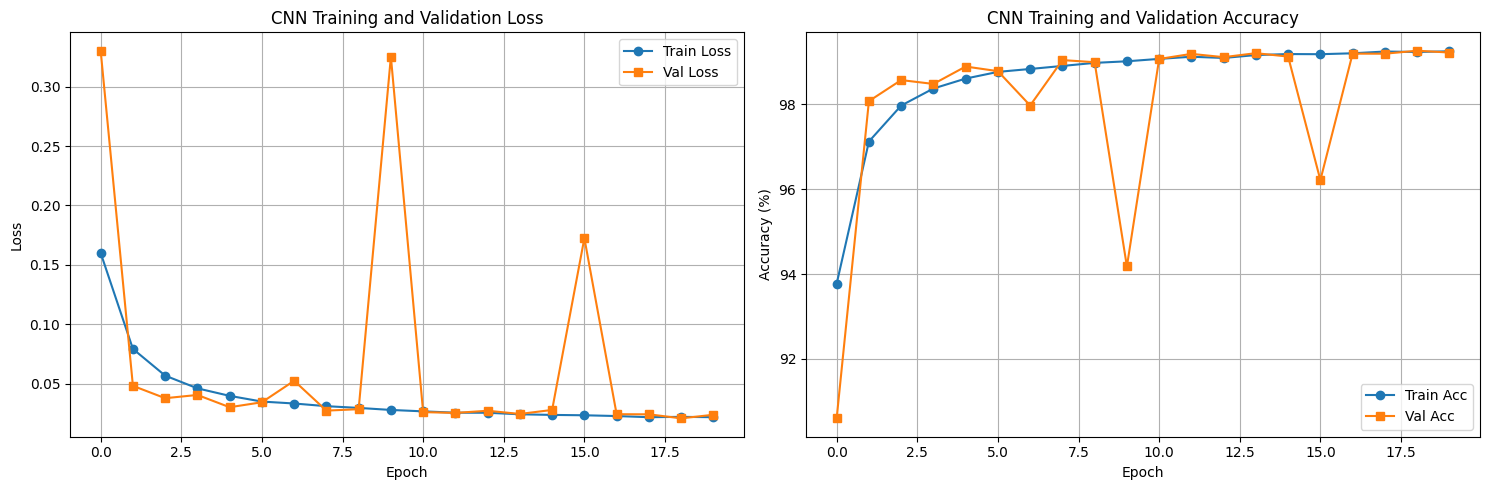

In [15]:
# Plot training curves for CNN
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(cnn_train_losses, label='Train Loss', marker='o')
axes[0].plot(cnn_val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('CNN Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(cnn_train_accs, label='Train Acc', marker='o')
axes[1].plot(cnn_val_accs, label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('CNN Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

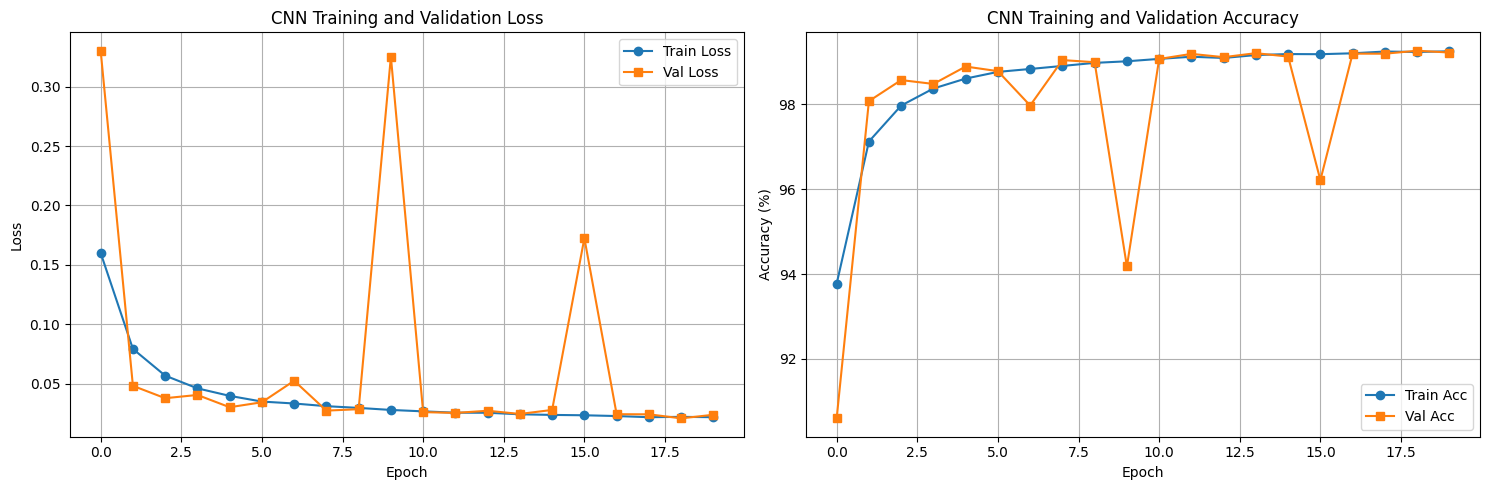

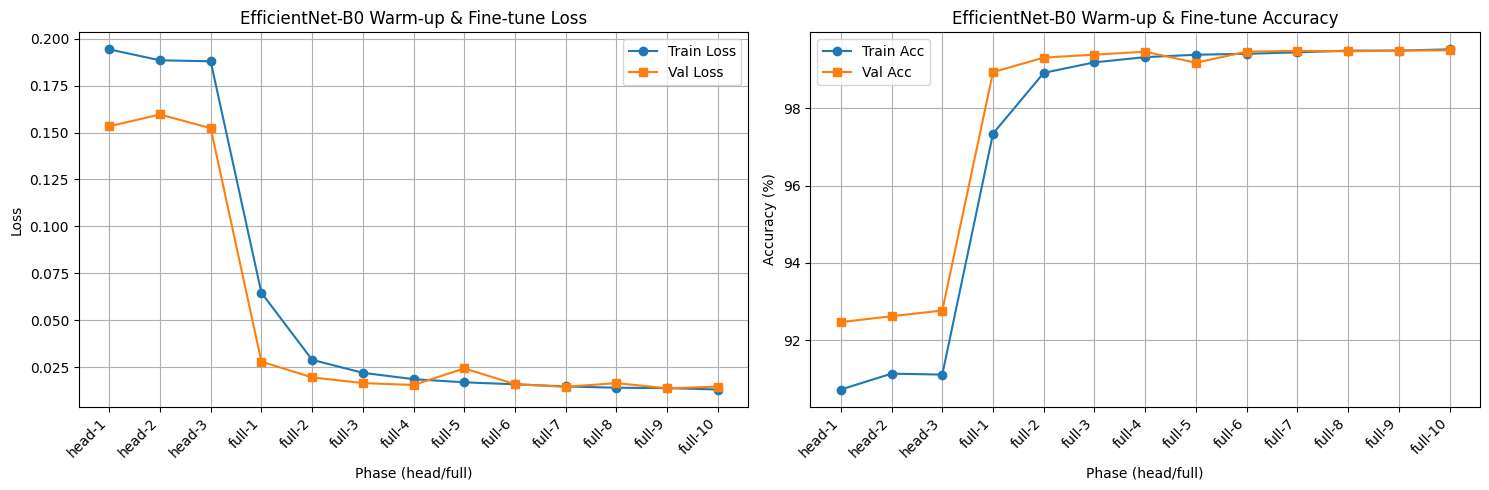

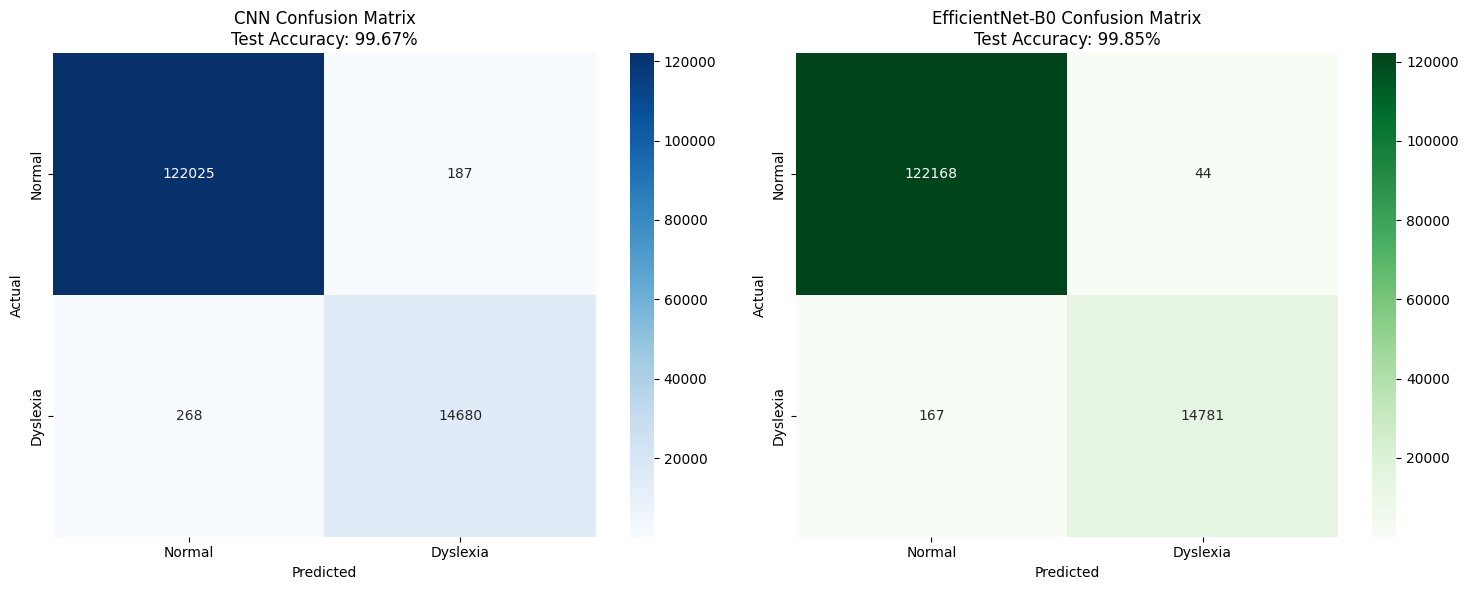

MODEL COMPARISON SUMMARY
Model           Val Acc      Test Acc     Test Loss   
------------------------------------------------------------
CNN                  99.26%      99.67%     0.0111
EfficientNet-B0      99.50%      99.85%     0.0045


In [48]:
# Plot training curves for CNN
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(cnn_train_losses, label='Train Loss', marker='o')
axes[0].plot(cnn_val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('CNN Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(cnn_train_accs, label='Train Acc', marker='o')
axes[1].plot(cnn_val_accs, label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('CNN Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plot training curves for EfficientNet-B0
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
phase_steps = list(range(1, len(effnet_train_losses) + 1))

axes[0].plot(phase_steps, effnet_train_losses, label='Train Loss', marker='o')
axes[0].plot(phase_steps, effnet_val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Phase (head/full)')
axes[0].set_ylabel('Loss')
axes[0].set_title('EfficientNet-B0 Warm-up & Fine-tune Loss')
axes[0].set_xticks(phase_steps)
axes[0].set_xticklabels(effnet_phase_labels, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(phase_steps, effnet_train_accs, label='Train Acc', marker='o')
axes[1].plot(phase_steps, effnet_val_accs, label='Val Acc', marker='s')
axes[1].set_xlabel('Phase (head/full)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('EfficientNet-B0 Warm-up & Fine-tune Accuracy')
axes[1].set_xticks(phase_steps)
axes[1].set_xticklabels(effnet_phase_labels, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# CNN confusion matrix
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=synthetic_dataset.classes,
            yticklabels=synthetic_dataset.classes)
axes[0].set_title(f'CNN Confusion Matrix\nTest Accuracy: {cnn_test_acc:.2f}%')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# EfficientNet-B0 confusion matrix
sns.heatmap(effnet_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=synthetic_dataset.classes,
            yticklabels=synthetic_dataset.classes)
axes[1].set_title(f'EfficientNet-B0 Confusion Matrix\nTest Accuracy: {effnet_test_acc:.2f}%')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Model comparison
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<15} {'Val Acc':<12} {'Test Acc':<12} {'Test Loss':<12}")
print("-" * 60)
print(f"{'CNN':<15} {best_cnn_val_acc:>10.2f}% {cnn_test_acc:>10.2f}% {cnn_test_loss:>10.4f}")
print(f"{'EfficientNet-B0':<15} {best_effnet_val_acc:>10.2f}% {effnet_test_acc:>10.2f}% {effnet_test_loss:>10.4f}")
print("=" * 60)


In [41]:
checkpoint = torch.load("/kaggle/input/cnn-classifier-pth/other/default/1/cnn_classifier (2).pth", map_location=device)
cnn_train_losses = checkpoint["train_losses"]
cnn_val_losses = checkpoint["val_losses"]
cnn_train_accs = checkpoint["train_accs"]
cnn_val_accs = checkpoint["val_accs"]
cnn_cm = checkpoint["cnn_cm"] 

KeyError: 'cnn_cm'

In [47]:
best_cnn_val_acc = checkpoint["val_acc"]


In [49]:
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def forward_hook(_, __, output):
            self.activations = output.detach()

        def backward_hook(_, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.fwd_handle = target_layer.register_forward_hook(forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(backward_hook)

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def __call__(self, input_tensor: torch.Tensor, class_idx: int | None = None):
        self.model.zero_grad()
        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        target = logits[:, class_idx]
        target.backward()

        gradients = self.gradients  # [B, C, H, W]
        activations = self.activations
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-6)
        return cam.squeeze().cpu().numpy(), class_idx


def plot_gradcam_overlay(image_tensor, cam, title="Grad-CAM"):
    img = image_tensor.squeeze().cpu().numpy()
    if img.ndim == 3:
        img = img.transpose(1, 2, 0)
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.title(title)
    plt.show()


def visualize_gradcam_sample(model, dataset, transform_ds, idx: int, target_layer: nn.Module, label_names):
    model.eval()
    raw_img, label = dataset[idx]
    input_tensor, _ = transform_ds[idx]
    input_tensor = input_tensor.unsqueeze(0).to(device)

    gradcam = GradCAM(model, target_layer)
    cam, pred_idx = gradcam(input_tensor)
    gradcam.remove()

    title = f"True: {label_names[label]} | Pred: {label_names[pred_idx]}"
    plot_gradcam_overlay(raw_img, cam, title)



Grad-CAM for sample idx 100


/tmp/ipykernel_47/713535826.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')
/tmp/ipykernel_47/191229588.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.squeeze(0).numpy() * 255).astype('uint8'), mode='L')


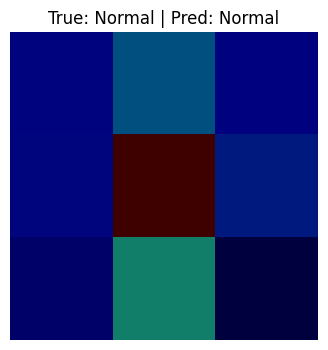

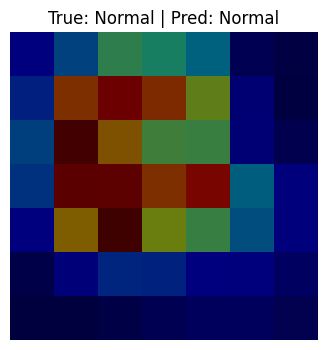

In [50]:
# Example: Grad-CAM visualization for CNN and EfficientNet-B0
sample_idx = 100  # change as needed
print(f"Grad-CAM for sample idx {sample_idx}")

# CNN target layer: last conv block
visualize_gradcam_sample(
    cnn_model,
    test_dataset,
    test_ds_cnn,
    sample_idx,
    target_layer=cnn_model.conv4,
    label_names=synthetic_class_names,
)

# EfficientNet target layer: last feature block
if 'effnet_model' in globals():
    visualize_gradcam_sample(
        effnet_model,
        test_dataset,
        test_ds_effnet,
        sample_idx,
        target_layer=effnet_model.features[-1],
        label_names=synthetic_class_names,
    )
else:
    print("EfficientNet model not available in this session")



In [54]:
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def forward_hook(_, __, output):
            self.activations = output.detach()

        def backward_hook(_, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.fwd_handle = target_layer.register_forward_hook(forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(backward_hook)

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def __call__(self, input_tensor: torch.Tensor, class_idx: int | None = None):
        self.model.zero_grad()
        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        target = logits[:, class_idx]
        target.backward()

        gradients = self.gradients  # [B, C, H, W]
        activations = self.activations
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-6)
        return cam.squeeze().cpu().numpy(), class_idx


def plot_gradcam_overlay(image_tensor, cam, title="Grad-CAM"):
    img = image_tensor.squeeze().cpu().numpy()
    if img.ndim == 3:
        img = img.transpose(1, 2, 0)
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.title(title)
    plt.show()


def visualize_gradcam_sample(model, dataset, transform_ds, idx: int, target_layer: nn.Module, label_names, model_name: str):
    model.eval()
    raw_img, label = dataset[idx]
    input_tensor, _ = transform_ds[idx]
    input_tensor = input_tensor.unsqueeze(0).to(device)

    gradcam = GradCAM(model, target_layer)
    cam, pred_idx = gradcam(input_tensor)
    gradcam.remove()

    title = f"{model_name} | True: {label_names[label]} | Pred: {label_names[pred_idx]}"
    plot_gradcam_overlay(raw_img, cam, title)



/tmp/ipykernel_47/713535826.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((self.images[idx] * 255).astype("uint8"), mode='L')


Grad-CAM for Normal sample idx 0


/tmp/ipykernel_47/191229588.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.squeeze(0).numpy() * 255).astype('uint8'), mode='L')


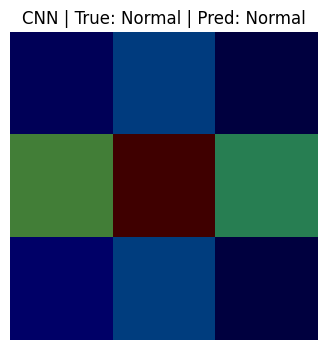

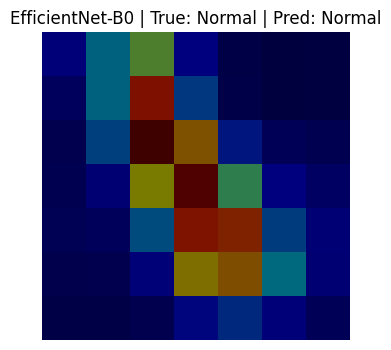

Grad-CAM for Dyslexia sample idx 116323


/tmp/ipykernel_47/191229588.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((img.permute(1, 2, 0).numpy() * 255).astype('uint8'), mode='RGB')


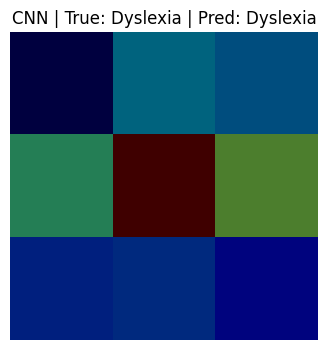

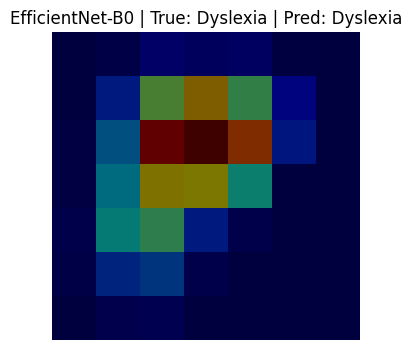

In [55]:
# Grad-CAM visualization for CNN and EfficientNet-B0 on Normal and Dyslexia samples

def find_sample_indices(label_value, count=1):
    indices = [i for i, (_, lbl) in enumerate(test_dataset) if lbl == label_value]
    if len(indices) < count:
        raise ValueError(f"Only found {len(indices)} samples for label {label_value}")
    return indices[:count]

label_cases = [(0, "Normal"), (1, "Dyslexia")]
for label_value, label_name in label_cases:
    idx = find_sample_indices(label_value)[0]
    print(f"Grad-CAM for {label_name} sample idx {idx}")

    visualize_gradcam_sample(
        cnn_model,
        test_dataset,
        test_ds_cnn,
        idx,
        target_layer=cnn_model.conv4,
        label_names=synthetic_class_names,
        model_name="CNN",
    )

    if 'effnet_model' in globals():
        visualize_gradcam_sample(
            effnet_model,
            test_dataset,
            test_ds_effnet,
            idx,
            target_layer=effnet_model.features[-1],
            label_names=synthetic_class_names,
            model_name="EfficientNet-B0",
        )
    else:
        print("EfficientNet model not available in this session")

